# Capstone: Customer Segmentation & Churn Prediction
### Telco Customer Churn Dataset

**Part 1** — Segment customers using K-Means (unsupervised, no churn label used)
**Part 2** — Predict churn using 3 classifiers, evaluated with metrics suited to imbalanced data



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load & clean the data

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Known data to fix
- `TotalCharges` is stored as text and has 11 blank entries — these all belong to customers with `tenure == 0` (brand-new customers who haven't been billed yet), so converted to numeric and fill with 0.
- `customerID` is just an identifier — not useful for modeling, so we drop it.


In [5]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
print("Missing TotalCharges before fill:", df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df = df.drop(columns=['customerID'])
print(df['Churn'].value_counts(normalize=True))

Missing TotalCharges before fill: 11
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


The churn rate is about **26.5%** — this is an imbalanced classification problem, so accuracy alone will be misleading later. Recall and F1 matter more.


## Part 1 — Customer Segmentation (K-Means)

We segment customers based on **behavior and spending only** — `Churn` is never used here, since this is unsupervised learning.


In [6]:
# Engineer a "number of services used" feature from the service columns
service_cols = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df['NumServices'] = df[service_cols].apply(lambda row: sum(v == 'Yes' for v in row), axis=1)

cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
X_cluster = df[cluster_features]

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)
X_cluster_scaled.shape

(7043, 4)

### Choose k with the elbow method + silhouette score

k=2: inertia=12829.5, silhouette=0.4670
k=3: inertia=8599.8, silhouette=0.4120
k=4: inertia=6451.7, silhouette=0.4187
k=5: inertia=5061.7, silhouette=0.3872
k=6: inertia=4225.4, silhouette=0.3734
k=7: inertia=3712.7, silhouette=0.3696


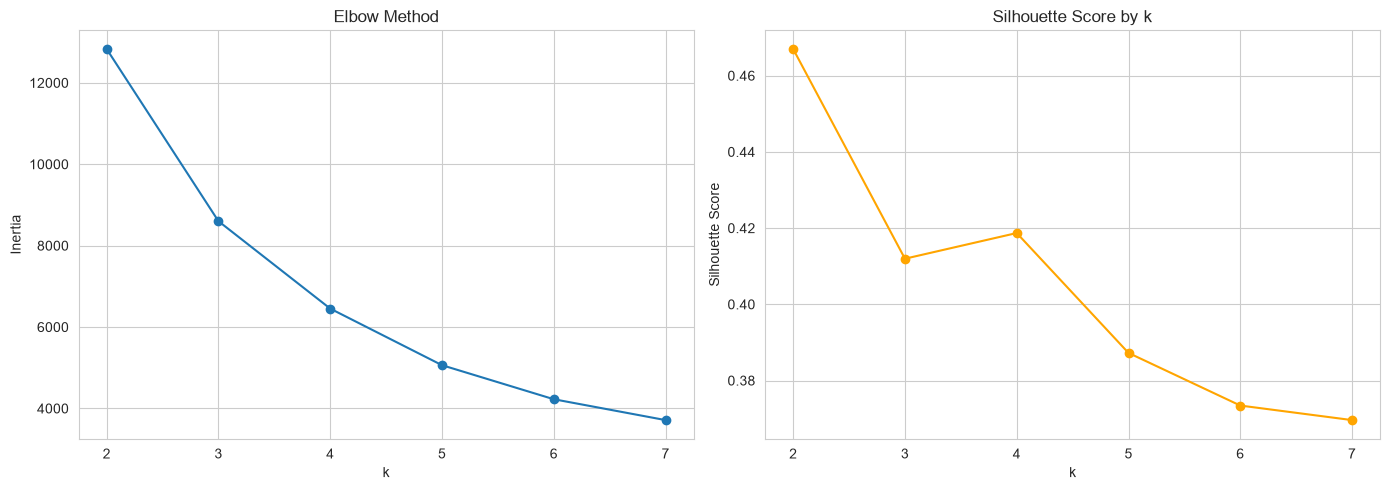

In [7]:
inertias, sil_scores = [], []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score by k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

**k=4** gives a strong silhouette score (~0.42) and, as shown below, produces clusters that map cleanly onto interpretable, real-world customer segments — so we go with k=4.


In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)
df['Cluster'].value_counts().sort_index()

Cluster
0    1804
1    1941
2    1080
3    2218
Name: count, dtype: int64

### Name each cluster based on its profile

In [9]:
profile = df.groupby('Cluster')[cluster_features].mean()
profile['Count'] = df['Cluster'].value_counts().sort_index()
profile['ChurnRate'] = df.groupby('Cluster')['Churn'].apply(lambda s: (s == 'Yes').mean())
profile

,tenure,MonthlyCharges,TotalCharges,NumServices,Count,ChurnRate
Cluster,,,,,,
0,9.388027,34.902688,284.928437,1.285477,1804,0.291020
1,59.339516,92.863344,5499.543612,5.795981,1941,0.151468
2,53.887963,32.933333,1751.687222,1.914815,1080,0.054630
3,16.986925,79.953291,1341.623738,3.628494,2218,0.446799


In [10]:
cluster_names = {
    0: 'New Customers',        # low tenure, low spend, few services
    1: 'High Value Loyal',     # long tenure, high spend, most services
    2: 'Loyal Low Spenders',   # long tenure, low monthly charges, few services -> lowest churn
    3: 'At Risk Customers'     # short-mid tenure, high monthly charges -> highest churn
}
df['Segment'] = df['Cluster'].map(cluster_names)
df[['Cluster','Segment']].drop_duplicates().sort_values('Cluster')

,Cluster,Segment
0,0,New Customers
12,1,High Value Loyal
3,2,Loyal Low Spenders
1,3,At Risk Customers


### Visualize the clusters

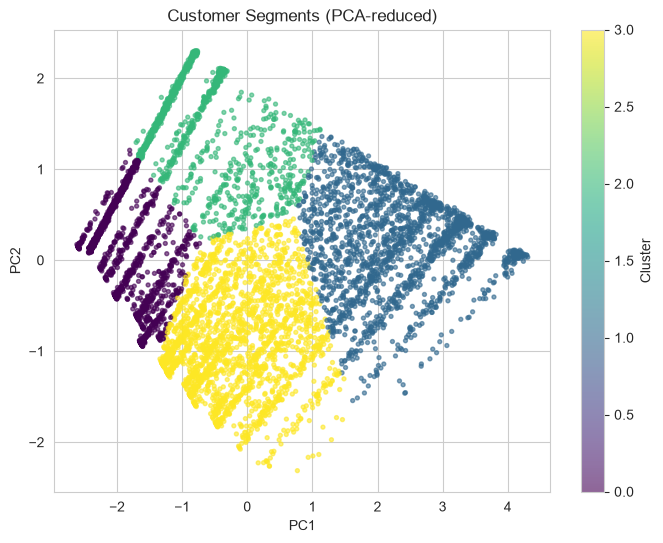

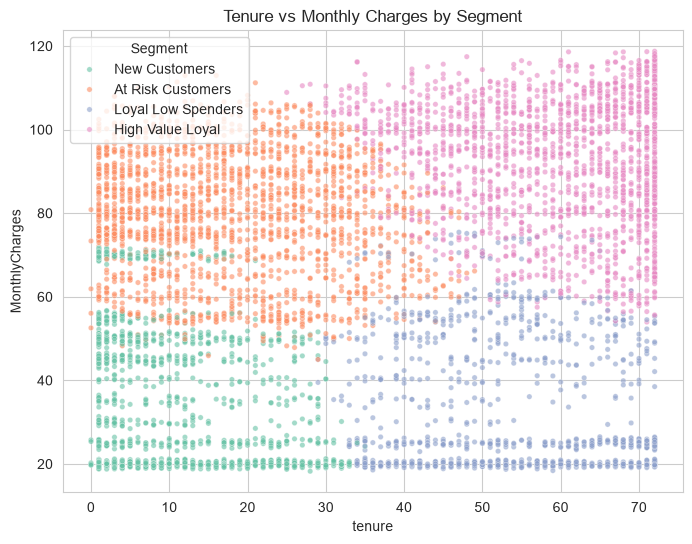

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', s=8, alpha=0.6)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Customer Segments (PCA-reduced)')
plt.colorbar(scatter, label='Cluster')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Segment', palette='Set2', s=15, alpha=0.6)
plt.title('Tenure vs Monthly Charges by Segment')
plt.show()

**Segment summary:**
- **New Customers** — low tenure, low spend, few services, 29% churn
- **High Value Loyal** — long tenure, high spend, most services, 15% churn
- **Loyal Low Spenders** — long tenure, low monthly charges, few extras — **lowest churn (5.5%)**
- **At Risk Customers** — short-to-mid tenure, high monthly charges — **highest churn (44.7%)**

This alone is actionable: "At Risk" customers are paying a lot but haven't stuck around — a strong candidate for retention offers.


## Part 2 — Churn Prediction

We predict `Churn` using the original features **plus** the cluster label, encode categoricals, split into train/test, and compare 3 models.


In [12]:
y = (df['Churn'] == 'Yes').astype(int)
df_features = df.drop(columns=['Churn', 'Segment'])  # keep numeric Cluster, drop text Segment

categorical_cols = df_features.select_dtypes(include='object').columns.tolist()
numeric_cols = [c for c in df_features.columns if c not in categorical_cols]
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

df_encoded = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)

feature_scaler = StandardScaler()
df_encoded[numeric_cols] = feature_scaler.fit_transform(df_encoded[numeric_cols])

print("Final feature matrix shape:", df_encoded.shape)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'Cluster']
Final feature matrix shape: (7043, 32)


C:\Users\Uswa Khalil\AppData\Local\Temp\ipykernel_11096\1370942688.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_features.select_dtypes(include='object').columns.tolist()


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    df_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))

Train: (5634, 32)  Test: (1409, 32)
Train churn rate: 0.265  Test churn rate: 0.265


### Train & evaluate 3 models

--- Logistic Regression ---
  Accuracy: 0.7381
  Precision: 0.5042
  Recall: 0.7941
  F1: 0.6168


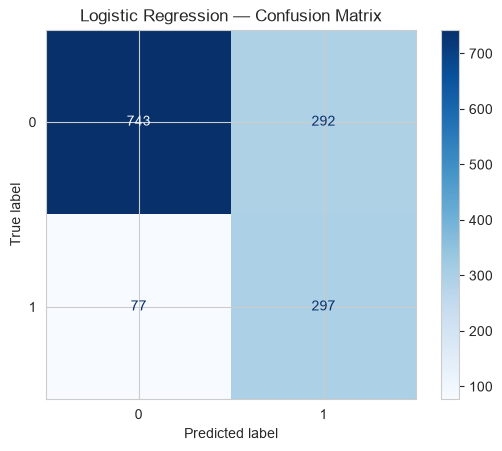

In [14]:
def evaluate(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metrics = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
    }
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.show()
    return model, metrics

log_model, log_metrics = evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)

--- Random Forest ---
  Accuracy: 0.7644
  Precision: 0.5471
  Recall: 0.6524
  F1: 0.5951


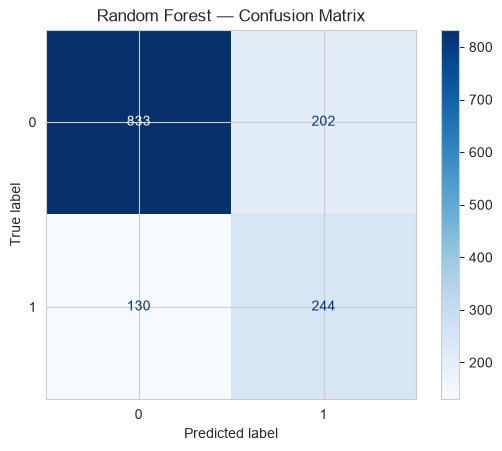

In [15]:
rf_model, rf_metrics = evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
)

--- XGBoost ---
  Accuracy: 0.7537
  Precision: 0.5238
  Recall: 0.7941
  F1: 0.6312


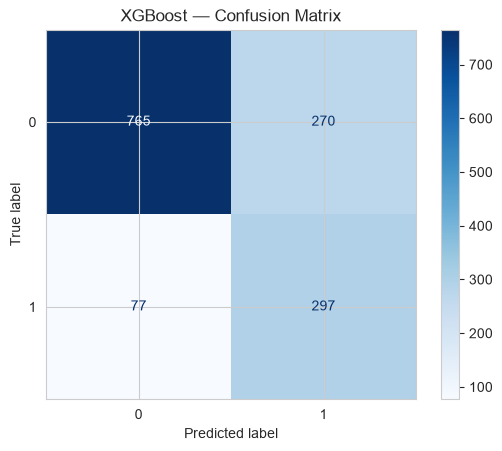

In [16]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model, xgb_metrics = evaluate(
    "XGBoost",
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                  scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
)

In [17]:
results_df = pd.DataFrame({
    'Logistic Regression': log_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T
results_df.round(4)

,Accuracy,Precision,Recall,F1
Logistic Regression,0.7381,0.5042,0.7941,0.6168
Random Forest,0.7644,0.5471,0.6524,0.5951
XGBoost,0.7537,0.5238,0.7941,0.6312


### Picking the best model

Since churn data is imbalanced, **Recall and F1** matter more than raw accuracy (missing an actual churner is costlier than a false alarm). Random Forest has the best accuracy but the worst recall — it plays it "safe" and misses over half the churners. **XGBoost** gives the best F1 score and ties Logistic Regression on recall (~79%) while beating it on precision, so we select **XGBoost** as the final model.


In [18]:
best_model = xgb_model
best_name = "XGBoost"
print(f"Selected model: {best_name}")
print(results_df.loc[best_name])

Selected model: XGBoost
Accuracy     0.753726
Precision    0.523810
Recall       0.794118
F1           0.631243
Name: XGBoost, dtype: float64


## Save models

In [19]:
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(cluster_scaler, 'cluster_scaler.pkl')
joblib.dump(feature_scaler, 'feature_scaler.pkl')
joblib.dump(list(df_encoded.columns), 'feature_columns.pkl')
joblib.dump(cluster_names, 'cluster_names.pkl')
joblib.dump(numeric_cols, 'numeric_cols.pkl')
joblib.dump(categorical_cols, 'categorical_cols.pkl')

print("All model artifacts saved:")
print("- churn_model.pkl        (best classifier)")
print("- kmeans_model.pkl       (segmentation model)")
print("- cluster_scaler.pkl     (scaler for clustering features)")
print("- feature_scaler.pkl     (scaler for churn model numeric features)")
print("- feature_columns.pkl    (final column order/names for the churn model)")
print("- cluster_names.pkl      (cluster number -> segment name mapping)")
print("- numeric_cols.pkl / categorical_cols.pkl (for preprocessing new input)")

All model artifacts saved:
- churn_model.pkl        (best classifier)
- kmeans_model.pkl       (segmentation model)
- cluster_scaler.pkl     (scaler for clustering features)
- feature_scaler.pkl     (scaler for churn model numeric features)
- feature_columns.pkl    (final column order/names for the churn model)
- cluster_names.pkl      (cluster number -> segment name mapping)
- numeric_cols.pkl / categorical_cols.pkl (for preprocessing new input)


## Summary

- **Segmentation**: 4 meaningful customer segments found via K-Means (k=4, silhouette ≈ 0.42), ranging from "Loyal Low Spenders" (5.5% churn) to "At Risk Customers" (44.7% churn).
- **Prediction**: XGBoost was the best of 3 models tested, balancing recall (catching actual churners) and precision.
- All artifacts are saved and ready to be loaded by the Streamlit app.
